# Machine Learning in Python - Project 

Due Friday, Apr 10th by 4 pm.

*Triptesh Biswas (s2857023), Arden Diakhate-Palme (s2818750)*

## Setup

*Install any packages here, define any functions if neeed, and load data*

In [1]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, f1_score, recall_score, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import chi2

import time
import warnings

In [2]:
random_state = 100

### Data Loading

In [3]:
df_fs = pd.read_spss("ExtendedDataSources/fs.sav")
df_wm = pd.read_spss("ExtendedDataSources/wm.sav")
df_mn = pd.read_spss("ExtendedDataSources/mn.sav")
df_hh = pd.read_spss("ExtendedDataSources/hh.sav")

In [4]:
# match individual men / women biological father / mother to child
df_hh_fs = df_hh.merge(df_fs, on=['HH1', 'HH2'], how='inner', suffixes=('_hh', '_fs'))
dup_cols = [c for c in df_hh_fs.columns if c.endswith('_hh')]
df_hh_fs = df_hh_fs.drop(columns=dup_cols)
df_hh_fs.columns = [c.replace('_fs', '') for c in df_hh_fs.columns]

df_hh_fs_wm = df_hh_fs.merge(df_wm, on=['HH1', 'HH2', 'LN'], how='left', suffixes=('_hh_fs', '_wm'))
dup_cols = [c for c in df_hh_fs_wm.columns if c.endswith('_hh_fs')]
df_hh_fs_wm = df_hh_fs_wm.drop(columns=dup_cols)
df_hh_fs_wm.columns = [c.replace('_hh_fs', '') for c in df_hh_fs_wm.columns]

df = df_hh_fs_wm.merge(df_mn, on=['HH1', 'HH2', 'LN'], how='left',suffixes=('_hh_fs_wm', '_mn'))
dup_cols = [c for c in df_hh_fs_wm.columns if c.endswith('_hh_fs_wm')]
df = df.drop(columns=dup_cols)
df.columns = [c.replace('_hh_fs_wm', '') for c in df.columns]

In [5]:
df_base = pd.read_csv("unicef_malawi.csv")
print(f"Provided dataset has {df_base.shape[1]} features, extended dataset has {df.shape[1]} features")

Provided dataset has 87 features, extended dataset has 1277 features


# Introduction

*This section should include a brief introduction to the task and the data (assume this is a report you are delivering to a professional body (e.g. UNICEF)).*

*Briefly outline the approaches being used and the conclusions that you are able to draw.*

The mental health of the next generation is a social priority, and poor mental health impacts on low- and middle-income communities disproportionately. Using UNICEF’s Multiple Indicator Cluster Survey (MICS) from Malawi, Africa, which collects information on the child, parent, and household environment, this report seeks to shed light on the following:
1. How depression impacts intergenerational experiences & society
2. Potential social & health policies to address factors that may cause depression.

To this end, we developed two models to determine whether a child is depressed, and which factors (variables in the MICS dataset) are the biggest contributors to that child's poor mental health.

# Exploratory Data Analysis and Feature Engineering

*Include a detailed discussion of the data with a particular emphasis on the features of the data that are relevant for the subsequent modeling. Including visualizations of the data is strongly encouraged - all code and plots must also be described in the write up. Think carefully about whether each plot needs to be included in your final draft and the appropriate type of plot and summary for each variable type - your report should include figures but they should be as focused and impactful as possible.*

*You should also split your data into training and testing sets, ideally before you look to much into the features and relationships with the target.*

*Additionally, this section should also motivate and describe any preprocessing / feature engineering of the data. Pipelines should be used and feature engineering steps that are be performed as part of an sklearn pipeline can be mentioned here but should be implemented in the following section.*

*All code and figures should be accompanied by text that provides an overview / context to what is being done or presented.*

Before diving into the data it helps to take a step back and take a look at the way the survey was conducted, and to do preliminary research to determine which modules to focus on, this will help us isolate the right features, which will reduce the final model's size.

After performing some high-level research into child mental health, we determined that the following modules were most important, and further filtered the features in each module to include only the ones we found most pertinent to predicting depression. 

1. Questionnaire for Children age 5-17 years:`FCF` Child Functioning, `PR` Parental Involvement, `FCD` Child Discipline, `CL` Child Labor, `FL` Child Learning
  
2. Questionnaire for Individual Women age 15-49 years: `LS` Life Satisfaction, `DV` Attitutdes Towards Domestic Violence, `MA` Marriage / Union, `TA` Tobacco and Alcohol Use

3. Questionnaire for Individual Men age 15-49 years: `MLS` Life Satisfaction, `MDV` Attitutdes Towards Domestic Violence, `MVT` Victimization, `MTA` Tobacco and Alcohol Use

4. Household Questionnaire: `HC` Household Characteristics, `ST` Social Transfers, `WS` Water and Sanitation, `ED` Education (3+)

For each module we further filtered out the features which we deemed unrelated to child mental health after preliminary analysis / common sense. Other features are redundant (i.e. only `NaN` values in column or only `NaN` and a string as unqiue values), and are excluded as well.

In [6]:
modules = ['FCF', 'PR', 'FCD', 'CL', 'FL',
           'LS', 'DV', 'MA', 'TA',
           'MLS', 'MDV', 'MVT', 'MTA',
           'HC', 'ST', 'WS', 'ED']

In [7]:
excl_features = ['FL26', 'FL26A', 'FL26B', 'FL26C', 'FL26D', 'FL26E', 'FL26F', 'FL26X', 'FL3',
                 'TA8B', 'MAF11', 'MAF11', 'MAF12', 'MA7', 'TA4',
                 'MTA8NR', 'MVT18NR', 'MTA8B', 'MTA12A', 'MAF3', 'MVT13', 'MVT2', 'MVT5', 'MVT6',
                 'WS10NR', 'WS12', 'WS7'
                ]

redundant_features = ['MTA8B', 'TA12X', 'MTA12A', 'MVT7B', 'MTA8X', 'MTA8E', 'FLINTRO', 'FL13', 'TA8X', 'MVT7NR', 
                      'TA13', 'MTA12X', 'TA8D', 'TA9', 'TA12B', 'MTA8C', 'TA12C', 'FLB_INTRO', 'MTA12NR', 'MTA12B', 
                      'TA8NR', 'MTA13', 'MTA12C', 'MTA8A', 'FL16', 'MTA9', 'MVT18B', 'FL18', 'MTA8D', 'TA12NR', 'TA8A', 
                      'MVT11', 'TA8C', 'MVT3', 'TA12A', 'TA5']

excl_features = excl_features + redundant_features 
excl_features.append('FCF26') # remove target variable from feature set

In [8]:
def get_features(df_in, modules, excl_features=[]):
    features = []
    for module in modules:
        features = features + [feature for feature in df_in.columns if feature.startswith(module) and feature not in excl_features]
    return features   
features = get_features(df, modules, excl_features)

In [9]:
def get_cardinality(df, features, rare_threshold = 0.01):
    rows = []
    for feature in features:
        # we examine the normalized proportion of unique answers for all features in set
        val_ct = df[feature].value_counts(dropna=False, normalize=True).sort_values(ascending=False)
        rare_rows_mask = val_ct < rare_threshold
        rows.append({
            'feature':      feature,
            'n_unique':     df[feature].nunique(dropna=True),
            'n_null':       df[feature].isnull().sum(),
            'top_category': val_ct.index[0],
            'top_pct':      val_ct.iloc[0],
            'rare_pct':     rare_rows_mask.mean(),
        })

    ret = pd.DataFrame(rows)
    ret.set_index("feature", inplace=True)
    return ret

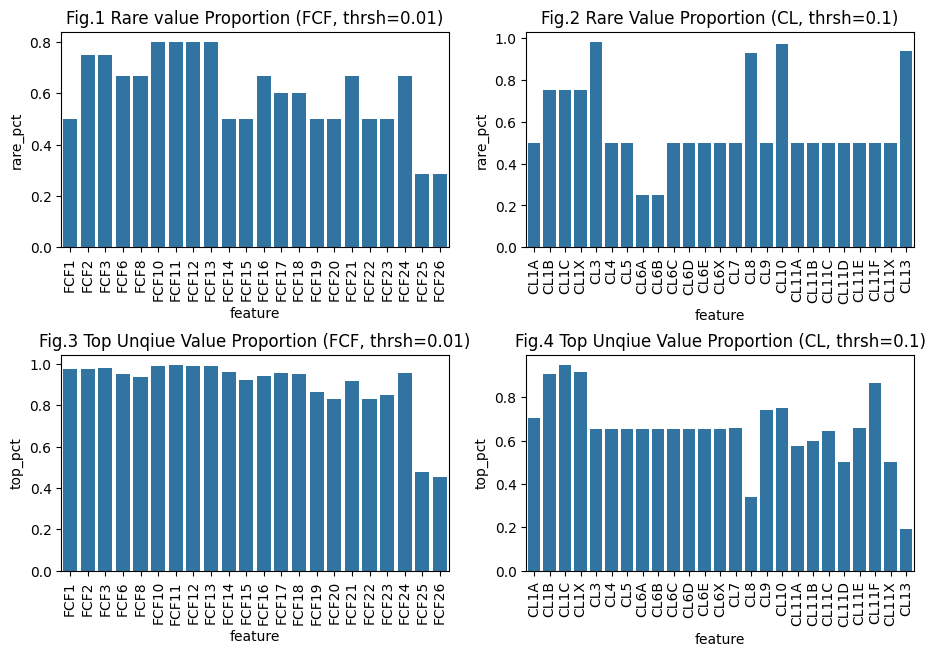

In [10]:
fig, ax = plt.subplots(2,2,figsize=(11,7))
df_card_fcf = get_cardinality(df, [feature for feature in df.columns if ('FCF' in feature)])
df_card_cl = get_cardinality(df, [feature for feature in df.columns if ('CL' in feature)], rare_threshold=0.1)

sns.barplot(df_card_fcf, x="feature", y="rare_pct", ax=ax[0,0])
ax[0,0].tick_params(axis='x', labelrotation=90)
ax[0,0].set_title("Fig.1 Rare value Proportion (FCF, thrsh=0.01)")

sns.barplot(df_card_cl, x="feature", y="rare_pct", ax=ax[0,1])
ax[0,1].tick_params(axis='x', labelrotation=90)
ax[0,1].set_title("Fig.2 Rare Value Proportion (CL, thrsh=0.1)")

sns.barplot(df_card_fcf, x="feature", y="top_pct", ax=ax[1,0])
ax[1,0].tick_params(axis='x', labelrotation=90)
ax[1,0].set_title("Fig.3 Top Unqiue Value Proportion (FCF, thrsh=0.01)")

sns.barplot(df_card_cl, x="feature", y="top_pct", ax=ax[1,1])
ax[1,1].tick_params(axis='x', labelrotation=90)
ax[1,1].set_title("Fig.4 Top Unqiue Value Proportion (CL, thrsh=0.1)")

plt.subplots_adjust(hspace=0.5)
plt.show()

In [11]:
df_card_fcf['top_category'].value_counts()

top_category
NO DIFFICULTY    13
NO                3
NEVER             2
Name: count, dtype: int64

The first row of the cardinality plots above show the percentage of per-feature rows (that take values in that feature's set of unique values) which occur less than $100\times$`rare_threshold`$\in\{0.01,0.1\}\%$ of the time. The second row show the percentage of each features rows in which the most-frequent unique value occurs. For features in the `FCF` module, the negative answer is most common (as seen in the output of `df_card_fcf['top_category'].value_counts()` above). 

Fig.3 shows that $40\%$ of the dataset consists of happy children (i.e. children never feeling depressed), and that most children are well functioning since `FCF_X` features usually correspond to questions concerning negative feelings (e.g. anxiety, difficulties, etc..) and the predominant answers are most of the time `NEVER` or `NO DIFFICULTY`. 

#### Preprocessing

Most of these columns are categorical, and even the "numerical" features have their constituents represented as strings, often with an additional `NO RESPONSE` or `DK` answer, necessitating the use of sophicsticated pipelines. See class `PreProcessor` section 6 in the code for more details.

In [12]:
num_features = ['CL13', 'CL8', 'CL3', 'CL10', 'FL20A', 'FL20B', 'FLB20A', 'FLB20B', 'FL2H', 'FL2M',
                'LS2', 'MA2', 'MA4', 'MA11', 'MA8Y', 'TA2', 'TA15', 'TA17',
                'MLS2', 'MTA2', 'MTA15', 'MTA17',
                'HC18D', 'HC18E', 'HC18G', 'HC18H', 'ST4N$1', 'ST4N$2', 'ST4N$3', 'ST4N$4', 'ST4N$5', 'WS4', 'WS5', 'WS6', 'HC3', 'HC16A', 'HC18A', 'HC18B', 'HC18C', 'HC18F']

After identifying numerical features, we identify a small subset of features whose corresponding questionare questions have binary responses (or binary with a third "don't know" or "no response/attempt" answer). These features will be encoded with one-hot-encoding.
Although one-hot encoding results in more features and higher dimensionality of the dataset $X\in\mathbb{R}^{n\times D}$, we will later determine which modules or features are redundant and apply PCA to reduce the number of features before fitting our models.

In [13]:
one_hot_features = ["FL1", "HC8", "MVT8", "MVT19", "MA5", "MA1"]

Finally, we use ordinal enoders where there is a sense of order to the response (e.g. levels of happiness, distance, or time duration) and one-hot encoding otherwise. We only consider certain columns for one-hot encoding (columns not specified are dropped so the final set of features is a subset of all features in the modules in the `modules` list above).

Additionally, we consider `NaN` responses to be indicative of no response i.e. this was an inputing error on the survey's administrator's part, who left the field blank when the participant failed to respond to the question.

In [14]:
class RepeatedOrdinalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, order):
        '''
        This class extends TransformerMixin (defines fit_transform) and BaseEstimator 
        It assumes that all columns share the same ordered categories, and allows including these kind of ordinal encoders in later pipelines
        '''
        self.order = order

    def fit(self, X, y=None):
        self.enc = OrdinalEncoder(
            # replicates ordinal categories so that each input row has same ordinal encoding
            categories=[self.order] * X.shape[1], 
            handle_unknown='use_encoded_value',
            unknown_value=np.nan
        )
        self.enc.fit(X)
        return self

    def transform(self, X):
        return self.enc.transform(X)

    # required for retrieving feature names downstream
    def get_feature_names_out(self, input_features=None):
        return input_features

In [15]:
class PreProcessor(ColumnTransformer):
    def __init__(self, df, features, one_hot_features=[], num_features=[]):
        self.num_features = num_features
        self.one_hot_features = one_hot_features
        self.ord_features = [] # filled later
        self.features = features # subset of df.columns
        self.df = df
        
        self.transformers= dict()
        self.transformers['ord'] = []
        self.transformers['num'] = []
        self.transformers['one_hot'] = []
        
        self.encode_ord()
        self.encode_num()
        self.encode_one_hot()
        
        transformers = self.transformers['one_hot'] + self.transformers['ord'] + self.transformers['num']
        super().__init__(transformers=transformers, verbose_feature_names_out=True,remainder='drop')
        
    def encode_ord(self):
        ordinal_answer_orders = dict()
        ordinal_answer_orders['yn'] = ['NO', 'YES', 'NO RESPONSE']
        ordinal_answer_orders['yndk'] = ['NO', 'YES', 'DK', 'NO RESPONSE']
        ordinal_answer_orders['cinr'] = ['CORRECT', 'INCORRECT', 'NOT REACHED']
        ordinal_answer_orders['cina'] = ['CORRECT', 'INCORRECT', 'NO ATTEMPT']
        ordinal_answer_orders['do'] = ['NO DIFFICULTY', 'SOME DIFFICULTY', 'A LOT OF DIFFICULTY']
        ordinal_answer_orders['freq'] = ['NEVER', 'A FEW TIMES A YEAR', 'MONTHLY', 'WEEKLY', 'DAILY', 'NO RESPONSE']
        ordinal_answer_orders['freq2'] = ['ONLY ONCE', 'MORE THAN ONCE']
        ordinal_answer_orders['freq3'] = ['ONE TIME', 'TWO TIMES', 'THREE OR MORE TIMES']
        ordinal_answer_orders['time_ago'] = ['MONTHS AGO', 'YEARS AGO']
        ordinal_answer_orders['time_ago2'] = ['YES, DURING THE LAST 12 MONTHS', 'NO, MORE THAN 12 MONTHS AGO']
        ordinal_answer_orders['people'] = ['ONE PERSON', 'THREE OR MORE PEOPLE', 'TWO PEOPLE'] 
        ordinal_answer_orders['grade'] = ['CLASS/YEAR/GRADE 1', 'CLASS/YEAR/GRADE 2', 'CLASS/GRADE 3', 'CLASS/YEAR/GRADE 4',
                                          'CLASS/GRADE 5', 'CLASS/GRADE 6', 'CLASS/YEAR/GRADE 7', 'CLASS/YEAR/GRADE 8']
        ordinal_answer_orders['edu'] = ['ECE', 'LOWER SECONDARY', 'PRIMARY', 'UPPER SECONDARY', 'VOCATION TRAINING', 'HIGHER']
        
        ordinal_answer_types = ['do', 'yn', 'yndk', 'cinr', 'cina', 'freq', 'freq2', 'freq3',
                        'time_ago', 'time_ago2', 
                        'grade', 'edu', 'people']
        ord_features_table = {key:[] for key in ordinal_answer_types}
        
        nan_resp = ['no response', 'dk', 'no attempt', 'not reached', 'no difficulty']

        for feature in set(self.features).difference(set(self.num_features)).difference(set(self.one_hot_features)):
            uresp = self.df[feature].unique()
        
            # 1. Replace nan-equivalent responses
            for resp in nan_resp:
                mask = np.array([resp in str(s).strip().lower() for s in uresp])
                if any(mask):
                    self.df.loc[self.df[feature].isnull(),feature] = str(uresp[mask][0])
        
            # 2. Replace missing values in binary columns with NO
            if(set(self.df[feature].unique()) == {'NO', 'YES', np.nan}):
                self.df.loc[self.df[feature].isnull(),feature] = 'NO'
                self.one_hot_features.append(feature)
                continue # these will be passed to one-hot encoder
                
            # 3. Features with yes/no or correct/incorrect responses should be one-hot encoded
            if((any('yes' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('no' in str(s).strip().lower() for s in self.df[feature].unique())) or \
               (any('correct' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('incorrect' in str(s).strip().lower() for s in self.df[feature].unique()))):
                one_hot_features.append(feature)
                continue # these will be passed to one-hot encoder
            
            # 4. Group the ordinal columns
            if any('no difficulty' in str(s).strip().lower() for s in self.df[feature].unique()) or \
               any('some difficulty' in str(s).strip().lower() for s in self.df[feature].unique()) or \
               any('a lot of difficulty' in str(s).strip().lower() for s in self.df[feature].unique()):
                ord_features_table['do'].append(feature)
        
            if (any('weekly' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('daily' in str(s).strip().lower() for s in self.df[feature].unique())):
                    ord_features_table['freq'].append(feature)
        
            if any('one time' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['freq2'].append(feature)
                
            if any('only once' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['freq3'].append(feature)
                
            if (any('years ago' in str(s).strip().lower() for s in self.df[feature].unique()) and \
                any('months ago' in str(s).strip().lower() for s in self.df[feature].unique())):
                    ord_features_table['time_ago'].append(feature)
        
            if any('class/year/grade' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['grade'].append(feature)
                
            if any('lower secondary' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['edu'].append(feature)
                
            if any('one person' in str(s).strip().lower() for s in self.df[feature].unique()):
                    ord_features_table['people'].append(feature)
                
        def replace_dk(X):
            X = pd.DataFrame(X).copy()
            X = X.astype(object)
            dk_variants = [v for v in X.stack().unique() if str(v).startswith('DK')]
            return X.replace(dk_variants, np.nan)
        
        def get_pipeline(answer_type):
            return Pipeline([
                ('replace_dk', FunctionTransformer(replace_dk, feature_names_out='one-to-one')),
                ('ordinal', RepeatedOrdinalEncoder(order=ordinal_answer_orders[answer_type])),
                ('impute', SimpleImputer(strategy='mean')),
            ])
        
        # 5. create column-wise transformers with an inputing strategy for ordinal encodings too
        for answer_type in ['edu', 'grade', 'time_ago']:
            self.transformers['ord'].append((answer_type, get_pipeline(answer_type), ord_features_table[answer_type]))

        for feature in ord_features_table['do']:
            if(len(self.df[feature].unique()) > 2):
                # this generalizes the last encoding since many different questions all have variants
                # of a negative response that starts of the form "Cannot __"
                cannot_labels = [v for v in self.df[feature].unique() if str(v).startswith('CANNOT')]
                order = ordinal_answer_orders['do'] + cannot_labels + ['NO RESPONSE']
                self.transformers['ord'].append((feature, OrdinalEncoder(categories=[order]), [feature]))
            else:
                self.one_hot_features.append(feature) # these are essentially binary features now

        for t in [ans for ans in ordinal_answer_types if ans not in ['do','edu','grade','time_ago']]:
                self.transformers['ord'].append((t, OrdinalEncoder(
                    categories=[ordinal_answer_orders[t]]*len(ord_features_table[t])),ord_features_table[t]))
            
    def encode_num(self):
        # 6. encode string responses in numerical features
        def parse_num_value(v):
            if isinstance(v, str):
                if v.startswith('NEVER') or v.startswith('MEMBERS'):
                    return 0.0
                if v in ['NO RESPONSE', 'DK']:
                    return np.nan
                v = v.replace('+','')
            return float(v)
        
        def clean_num_col(X):
            X = X.copy()
            for col in X.columns:
                X[col] = X[col].apply(parse_num_value)
            return X
        
        self.transformers['num'].append(('num', Pipeline([
            ('clean', FunctionTransformer(clean_num_col, feature_names_out='one-to-one')),
            ('impute', SimpleImputer(strategy='mean')), # mean inputer 
        ]), self.num_features))
        
    def encode_one_hot(self):
        self.transformers['one_hot'].append(('one_hot', OneHotEncoder(drop='first'), self.one_hot_features))


The `PreProcessor` class above extends `ColumnTransformer` and allows for custom ordinal encoding and numerical encoding. 

**Part 1** addresses the `NaN` values. These null entries are replaced by the appropriate question response in `nan_resp` based on the unique values for that feature.

**Part 4** appears daunting but this is just creating a mapping between features and ordinal encoding types so that the right transformers can be created later; it does so by checking whether unique responses include certain keywords and routes those features to an ordinal encoding type.

**Part 5** in class member function `encode_ord()` requires more discussion. Several features could be ordinal encoded this entails questionaire responses to for instance grade-level or education level. For these answer types, we assume that a no-response would be an average response (so we take the average encoding of the level to be that participant's answer). 

This class allows for modular reconfiguration of the preprocessor pipeline, so that we can easily add and remove features to the encodings which we deem necessary and/or significant

In [16]:
pre_processor = PreProcessor(df, features, num_features=num_features, one_hot_features=one_hot_features)

Since we are dealing with binary classification of no feelings of depression vs any feelings of depression, we encode the target variable as follows:

In [17]:
for df_it in [df, df_base]:
    target_mask = df_it['FCF26'].isnull() | (df_it['FCF26'] == 'NO RESPONSE') | (df_it['FCF26'] == 'NEVER')
    df_it['FCF26'] = (target_mask).astype(bool)

In [18]:
# pre_processor.fit_transform(X_train[features])

In [19]:
features = get_features(df, modules, excl_features)
from collections import Counter
for x,n in Counter(features).items():
    if(n > 1):
        print(x, n)

#### Exploratory Data Analysis

In [20]:
y = df['FCF26']
X = df.drop(columns=['FCF26'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

df_train = X_train.copy() # create a separate copy to avoid modifying X_train
df_train['FCF26'] = y_train

In [21]:
len(features)

433

In [22]:
len(set(features))

433

In [23]:
pre_processor.fit_transform(X_train[features])

array([[ 1.        ,  0.        ,  0.        , ...,  0.29423278,
         0.07083225,  5.1813424 ],
       [ 1.        ,  0.        ,  0.        , ...,  0.29423278,
         0.07083225,  5.1813424 ],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , 30.        ],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
         0.        , 18.        ],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.        ,  0.        ,  0.        , ...,  0.29423278,
         0.07083225,  5.1813424 ]], shape=(14380, 675))

In [27]:
%%capture
df_clean = pd.DataFrame(pre_processor.fit_transform(X_train[features]), columns=pre_processor.get_feature_names_out())

The dataset is split into training and testing subsets using `train_test_split`, with `test_size=0.2`, a fixed `random_state=100` for reproducibility, while preserving the class distribution through the use of `stratify=y`. Stratification ensures that both the training and test sets maintain approximately the same proportion of each target class, which is particularly important in preventing underrepresentation of minority classes and leads to more reliable model evaluation.

#### Feature Selection

We perform Chi-squared tests to narrow-down which features are dependent with the target variable.
Let $X$ be a categorical covariate (i.e. a feature in `X_train`) taking values in set $S=\{X_0,\ldots,X_k\}$ where $k\in\mathbb{Z}$, and let $Y$ be the target feature (i.e. child depression binary variable `FCF26`). 

$ \newcommand{\ind}{\perp\!\!\!\!\perp} $
Let $\text{H}_0: X\ind Y$. We will use significance level $\alpha=5\%$.

We then calculate Cramer's V for the response variable $V=\sqrt{\frac{\chi^2}{n}}$ where $n$ is the number of observations in the dataset and $\chi^2$ is the Chi-squared statistic. This statistic measures the dependence of $X$ on $Y$, and is a reasonable statistic to include because the $\chi^2$ scales linearly with $n$.

We perform this statistical test for all encoded features extracted from the `modlues` list.

In [28]:
def get_features_pre(df_in, modules, excl_features=[]): 
    features = []
    for module in modules:
        features = features + [feature for feature in df_in.columns if (module in feature) and feature not in excl_features]
    return features

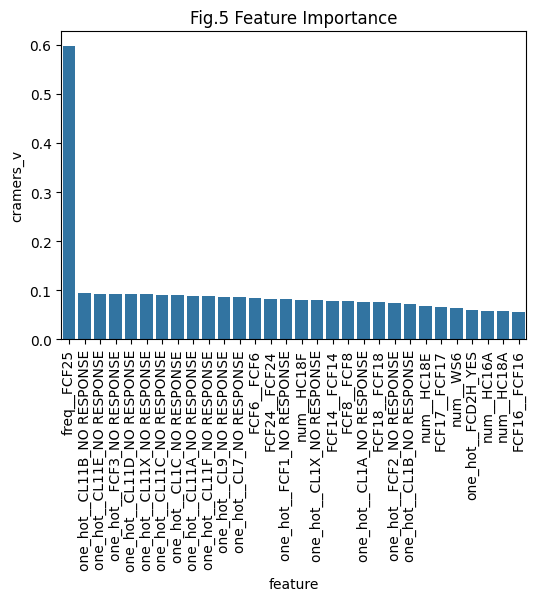

,chi2,log_chi2,p_value,cramers_v
feature,,,,
freq__FCF25,5134.877829,8.543811,0.000000e+00,0.597566
one_hot__CL11B_NO RESPONSE,125.525122,4.832506,3.906135e-29,0.093430
one_hot__CL11E_NO RESPONSE,123.178686,4.813636,1.274394e-28,0.092553
one_hot__FCF3_NO RESPONSE,123.178686,4.813636,1.274394e-28,0.092553
one_hot__CL11D_NO RESPONSE,122.034085,4.804300,2.269060e-28,0.092122


In [60]:
cleaned_features = get_features_pre(df_clean, modules)
chi2_scores, p_values = chi2(df_clean[cleaned_features], y_train)
cramers_v = np.sqrt(chi2_scores / y_train.shape[0])
df_imp = pd.DataFrame({
    'feature': cleaned_features,
    'chi2': chi2_scores,
    'log_chi2': np.log(chi2_scores),
    'p_value': p_values,
    'cramers_v': cramers_v,
}).sort_values('cramers_v',ascending=False)
df_imp.set_index('feature',inplace=True)

fig,ax = plt.subplots(1,1,figsize=(6,4))
sns.barplot(df_imp.iloc[:30], x='feature', y='cramers_v', ax=ax)
ax.tick_params(axis='x', labelrotation=90)
ax.set_title("Fig.5 Feature Importance")
plt.show()

display(df_imp.loc[df_imp.iloc[:5].index])

Figure 5 shows a $v>\delta$ for feature `FCF25`, which corresponds to survey question "I would like to know how often (name) seems very anxious, nervous or worried." with answers: `[Daily, Weekly, Monthly, A few times a year, Never]`. 
Since depression often comes with anxiety ([citation](https://link.springer.com/article/10.1007/s00406-016-0684-7)), it comes as no surprise that these two variables are dependent. However, due psychological association of the two states, `FCF25` may function as a proxy for depression itself (i.e. target variable `FCF26`), so we may be justified in removing it from the training set. 

Moreover, the table above shows that although `CL11B` and `CL11E` one-hot encodings $p<<\alpha$ (i.e. we strongly reject $\text{H}_0$ for these features, $v<0.1$ so these variables do not hold much signal.

$ \newcommand{\ind}{\perp\!\!\!\!\perp} $
Although we reject the null hypothesis, in other words, the data supports *dependence* $P(Y=y|X=x)\neq P(Y=y)$,
we have that $v<\delta\implies P(Y=1|\,X=X_1)\approx P(Y=1|\,X=X_i)$ where $i\in\{1,\ldots,k\}$

Knowing this, we can move forward in our modeling with adjusted expectations. 

#### PCA

In [20]:
%%capture
eda_pipe = Pipeline([
    ('pre',pre_processor),
    ('pca', PCA())
])
eda_pipe.fit_transform(X_train)

In [21]:
proportion_of_variance = eda_pipe['pca'].explained_variance_ratio_
proportion_of_variance_cum = np.cumsum(proportion_of_variance)

optimal_components = np.argmax(proportion_of_variance_cum >= 0.95) + 1
total_variance_explained = proportion_of_variance_cum[optimal_components-1] * 100

print(f"Optimal number of components: {optimal_components}")
print(f"Total percentage of variance explained by optimal components: {total_variance_explained:.4f}")

Optimal number of components: 13
Total percentage of variance explained by optimal components: 95.3504


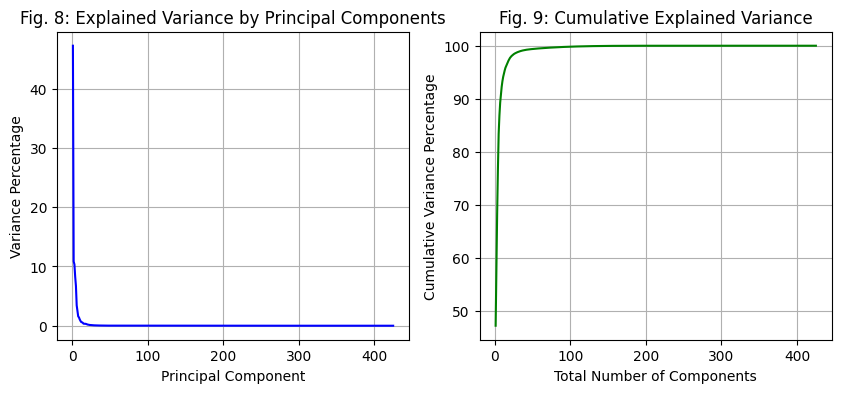

In [22]:
fig,ax = plt.subplots(1,2,figsize=(10,4))

ax[0].plot(range(1, len(proportion_of_variance) + 1), proportion_of_variance * 100, 'b-')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Variance Percentage')
ax[0].set_title('Fig. 8: Explained Variance by Principal Components')
ax[0].grid(True)

ax[1].plot(range(1, len(proportion_of_variance_cum) + 1), proportion_of_variance_cum * 100, 'g-')
ax[1].set_xlabel('Total Number of Components')
ax[1].set_ylabel('Cumulative Variance Percentage')
ax[1].set_title('Fig. 9: Cumulative Explained Variance')
ax[1].grid(True)

plt.show()

This redundancy observed in the correlation analysis is further supported by principal `component analysis (PCA)`, which shows that 13 components explain approximately 95.3% of the total variance. This indicates that a lower-dimensional representation can effectively preserve most of the underlying signal.

# Model Fitting and Tuning

*In this section you should detail and motivate your choice of model and describe the process used to refine, tune, and fit that model. You are encouraged to explore different models but you should NOT include a detailed narrative or code of all of these attempts. At most this section should very briefly mention the methods explored and why they were rejected - most of your effort should go into describing the final model you are using and your process for tuning and validating it.*

*This section should include the full implementation of your final model, including all necessary validation. As with figures, any included code must also be addressed in the text of the document.*

*You should also include a baseline model of your choice and provide a comparison of your model with the baseline model on the test data. You should briefly describe the baseline model considered.*

All model development activities including exploratory data analysis, feature engineering, model training, and hyperparameter tuning are conducted exclusively on the training set (`X_train`, `y_train`). The test set (`X_test`, `y_test`) is held out entirely and not exposed to any fitting or tuning procedures, ensuring an unbiased evaluation.

We begin with an interpretable baseline model using `Logistic Regression`, chosen for its simplicity. This baseline provides a clear reference point against which more complex modeling choices can be evaluated. To improve performance while retaining interpretability, we incorporate `StandardScaler` and `PCA` within a single pipeline.

In [23]:
y_b = df_base['FCF26']
X_b = df_base.drop(columns=['FCF26'])
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, random_state=random_state, stratify=y_b)

In [24]:
features_base = get_features(df_base, modules, excl_features)
pre_processor_base = PreProcessor(df_base, features_base, 
                                num_features=list(set(num_features).intersection(set(features_base))), 
                                one_hot_features=list(set(one_hot_features).intersection(set(features_base)))) 

In [25]:
pipeline_logistic_base = Pipeline([
    ('pre', pre_processor_base),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=random_state)),
    ('classifier', LogisticRegression(max_iter=5000,random_state=random_state)) # default L2 regularization
])

In [26]:
pipeline_logistic_base.fit(X_train_b[features_base],y_train_b)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,df,HH1... x 87 columns]
,features,"['FCD2A', 'FCD2B', ...]"
,one_hot_features,"['WS15', 'FCD2I', ...]"
,num_features,"['CL3', 'MA2', ...]"
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True


In [27]:
pipeline_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=random_state)),
    ('classifier', LogisticRegression(max_iter=5000,random_state=random_state)) # default L2 regularization
])

pipeline_logistic.fit(X_train[features], y_train)

ValueError: could not convert string to float: 'NO'

As we have included PCA in the pipeline, `L2 regularization` is the more appropriate choice for logistic regression. PCA transforms the original features into a set of orthogonal (uncorrelated) components and captures the most important variance in a lower dimensional space. Thus, the primary advantage of L1 regularization (feature selection) is less relevant here. Hence, L2 regularization is better suited here as it shrinks coefficients smoothly and provides greater numerical stability.

In [ ]:
y_train_pred = pipeline_logistic.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_accuracy:.4f}")

In [ ]:
print(classification_report(y_train, y_train_pred))

In [ ]:
warnings.simplefilter("ignore") # ignore deprecation warnings
param_grid_logistic = {
    'classifier__C': np.linspace(0, 10, 100)  # 100 values between 0 and 10
}

grid_logistic  = GridSearchCV(
    pipeline_logistic,
    param_grid_logistic,
    cv=5,
    scoring='recall',
    n_jobs=-1 # use all CPU cores
)

grid_logistic.fit(X_train, y_train)

print("Params: ", grid_logistic.best_params_)
print("Avg CV Recall: ", grid_logistic.best_score_)

The model is now refined through hyperparameter tuning using cross-validated grid search, focusing on the regularization strength parameter `C`. This process identifies an optimal value of `C = 8.38`. The resulting tuned logistic regression model serves as our primary candidate.

In [ ]:
pipeline_logistic_opt = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=random_state)),
    ('classifier', LogisticRegression(max_iter=5000, C=8.38, random_state=random_state))
])

pipeline_logistic_opt.fit(X_train, y_train)

In [ ]:
y_train_pred = pipeline_logistic_opt.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_accuracy:.4f}")

We now check `Support Vector Classifier (SVC)` model to evaluate whether capturing potential non-linear relationships in the data can improve predictive performance beyond the logistic regression baseline.

In [ ]:
pipeline_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=0.95, random_state=random_state)),
    ("svc",    SVC(kernel="rbf", gamma="scale", random_state=random_state)),
])

In [ ]:
C = np.linspace(0.1, 10, 20)

cv = GridSearchCV(
    pipeline_svc,
    param_grid = {'svc__C': C },
    cv = KFold(5, shuffle = True, random_state = 0),
    scoring='recall'
)

start = time.time()
cv.fit(X_train, y_train)
end = time.time()

print(f"Total training time: {end - start:.4f} seconds")

print("Params: ", cv.best_params_)
print("Avg Recall: ", cv.best_score_)

In [ ]:
pipeline_svc_opt = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=0.95, random_state=random_state)),
    ("svc",    SVC(kernel="rbf", C = 3.75, gamma="scale", random_state=random_state)),
])

pipeline_svc_opt.fit(X_train, y_train)

In [ ]:
y_train_pred = pipeline_svc_opt.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_accuracy:.4f}")

In [ ]:
lr_recall_cv = cross_val_score(pipeline_logistic_opt, X_train, y_train, cv=5, scoring='recall')
svc_recall_cv = cross_val_score(pipeline_svc_opt, X_train, y_train, cv=5, scoring='recall')

lr_accuracy_cv = cross_val_score(pipeline_logistic_opt, X_train, y_train, cv=5, scoring='accuracy')
svc_accuracy_cv = cross_val_score(pipeline_svc_opt, X_train, y_train, cv=5, scoring='accuracy')

print(f"CV: Logistic Regression Recall Score: {lr_recall_cv.mean():.3f}")
print(f"CV: SVC Recall Score: {svc_recall_cv.mean():.3f}")
print(f"\nCV: Logistic Regression Accuracy Score: {lr_accuracy_cv.mean():.3f}")
print(f"CV: SVC Accuracy Score: {svc_accuracy_cv.mean():.3f}")

During the model selection process, Logistic Regression and Support Vector Classifier (SVC) methods are evaluated. Initially, SVC appeared to be better model with a higher training accuracy of 89% compared to 85% of Logistic Regression. However, when cross-validation was performed, Logistic Regression achieved a CV accuracy score of 85.3%, almost identical to its training accuracy. Thus, the model is generalized well and not overfitting. On the other hand, SVC dropped CV accuracy to 83.8%, which is a 5.2% drop from training to cross-validation. It is a clear sign of overfitting. Based on this evidence, Logistic Regression is selected as the final model.

In [ ]:
y_test_pred = pipeline_logistic_opt.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
print(classification_report(y_test, y_test_pred))

# Interpretation, Discussion & Conclusions

*In this section you should provide a general overview of your final model, its performance, and reliability. You should discuss what the implications of your model are in terms of the included features, estimated parameters and relationships, predictive performance, and anything else you think is relevant.*

*This should be written with a target audience of a government official, who understands the issues associated with mental health but may only have university level mathematics (not necessarily postgraduate statistics or machine learning). Your goal should be to highlight to this audience how your model can useful. You should also discuss potential limitations or directions of future improvement of your model.*

*Finally, you should include recommendations on factors that may increase the risk of depression, which may be useful for the government officials and health care workers to improve their understanding of the condition, and potentially assit in the development of effective social and health policies and interventions.*

*Keep in mind that a negative result, i.e. a model that does not work well predictively, that is well explained and justified in terms of why it failed will likely receive higher marks than a model with strong predictive performance but with poor or incorrect explanations / justifications.*

# Generative AI statement

*Include a statement on how generative AI was used in the project and report.*

# References

*Include references if any*